# Haenesl Data Quality Challenge
In this notebook, I address the coding challenge from Haensel as part of the recruitment from for a Data Scientist role.

## Simple reading guide
- **Q1** checks whether Adwords cost data is fully reflected in session tracking.
- **Q2** checks whether conversions look stable over the available dates.
- **Q3** reconciles the tracked conversions with the backend truth.
- **Q4** checks whether attribution weights and customer journeys make sense.
- **Q5** checks whether channel labels and channel volumes look stable.
- **Q6** highlights a few additional quality flags.


In [ ]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (10, 4.5)

In [78]:
db_path = Path("data/challenge.db")
conn = sqlite3.connect(db_path)

print("Using database:", db_path)

Using database: data/challenge.db


## 0) Basic overview

Let's see if all tables in the schema actually exist in the database drop.

In [4]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """
, conn)

tables

,name
0,api_adwords_costs
1,attribution_customer_journey
2,conversions
3,conversions_backend
4,session_sources


How large (how many rows) each table is?

In [5]:
for table_name in tables["name"]:
    rows = pd.read_sql_query(f"SELECT COUNT(*) AS rows FROM {table_name}", conn).iloc[0, 0]
    print(f"{table_name:30s} {rows:,}")


api_adwords_costs              2,987
attribution_customer_journey   22,499
conversions                    16,954
conversions_backend            17,283
session_sources                1,616,702


Are the tables' time ranges totally consistent?

In [6]:
date_ranges = []

for table_name, date_col in [
    ("session_sources", "event_date"),
    ("conversions", "conv_date"),
    ("conversions_backend", "conv_date"),
    ("api_adwords_costs", "event_date"),
]:
    rng = pd.read_sql_query(
        f"SELECT MIN({date_col}) AS min_date, MAX({date_col}) AS max_date FROM {table_name}",
        conn
    )
    date_ranges.append({
        "table": table_name,
        "date_column": date_col,
        "min_date": rng.loc[0, "min_date"],
        "max_date": rng.loc[0, "max_date"],
    })

pd.DataFrame(date_ranges)


,table,date_column,min_date,max_date
0,session_sources,event_date,2021-07-01,2021-07-31
1,conversions,conv_date,2021-07-15,2021-07-31
2,conversions_backend,conv_date,2021-07-15,2021-07-31
3,api_adwords_costs,event_date,2021-07-01,2021-07-31


Two tables beging from first of July whereas the other two begin mid July. So there is tiny incosistency between them. <br>
However, those needed to match still do.

# Q1) Are the costs in `api_adwords_costs` fully covered in `session_sources`?

### What we want here
For the same **date + campaign_id**, compare:

- what the ad platform says was spent (`api_adwords_costs`)
- what the session tracking table contains (`session_sources`)

If the two tables are aligned, then:
- API cost should be close to the sum of session CPC
- API clicks should be close to the number of session rows

### Why the join starts from the API table
The task asks whether API cost is **covered by** session data, so the API table is the reference set we preserve with a `LEFT JOIN`.


### Compute campaign cost and click-events' counts in both tables and comapre.

In [7]:
q1 = pd.read_sql_query(
    """
    WITH sess AS (
        SELECT
            event_date,
            campaign_id,
            COUNT(*) AS session_rows,
            SUM(cpc) AS session_cost
        FROM session_sources
        GROUP BY event_date, campaign_id
    ),
    api AS (
        SELECT
            event_date,
            campaign_id,
            SUM(cost) AS api_cost,
            SUM(clicks) AS api_clicks
        FROM api_adwords_costs
        GROUP BY event_date, campaign_id
    )
    SELECT
        a.event_date,
        a.campaign_id,
        a.api_cost,
        a.api_clicks,
        COALESCE(s.session_rows, 0) AS session_rows,
        COALESCE(s.session_cost, 0) AS session_cost,
        ROUND(a.api_cost - COALESCE(s.session_cost, 0), 6) AS cost_gap,
        a.api_clicks - COALESCE(s.session_rows, 0) AS click_gap

    FROM api a
    LEFT JOIN sess s
        ON a.event_date = s.event_date
       AND a.campaign_id = s.campaign_id
    ORDER BY a.event_date, a.campaign_id
    """
, conn)

print("Overview of the data:")
print(q1.head().to_string())


Overview of the data:
   event_date      campaign_id  api_cost  api_clicks  session_rows  session_cost  cost_gap  click_gap
0  2021-07-01   campaign_id_10    292.73         266           292       292.807    -0.077        -26
1  2021-07-01  campaign_id_100     11.57          17            17        11.572    -0.002          0
2  2021-07-01  campaign_id_101      8.90          15            16         8.899     0.001         -1
3  2021-07-01  campaign_id_103      6.01           7             7         5.460     0.550          0
4  2021-07-01  campaign_id_106     62.66          49            46        62.672    -0.012          3


### Aggregated results:

In [8]:
api_cost_total = q1["api_cost"].sum()
session_cost_total = q1["session_cost"].sum()
api_clicks_total = q1["api_clicks"].sum()
session_rows_total = q1["session_rows"].sum()

print(f"Total API cost:      {api_cost_total:,.2f}")
print(f"Total session cost:  {session_cost_total:,.2f}")
print(f"Cost gap:            {api_cost_total - session_cost_total:,.2f}")
print(f"Cost coverage %:     {session_cost_total / api_cost_total * 100:.2f}%")
print(f"Click coverage %:    {session_rows_total / api_clicks_total * 100:.2f}%")


Total API cost:      455,399.80
Total session cost:  442,453.33
Cost gap:            12,946.48
Cost coverage %:     97.16%
Click coverage %:    93.18%


**Cost coverage = 97%**

It is not perfect, so there is still a **reconciliation gap**:

- Some **campaign-days are missing**
- Some **costs are under-recorded**
- Some **campaigns do not match cleanly**



**Click coverage ≈ 93%** suggests that about **7% of ad clicks** are not showing up as matched sessions.

That can happen because:

- Some clicks were **not tracked as sessions**
- Campaign IDs / dates do **not match perfectly**
- Session logging **missed some traffic**
- API and session systems **record events differently**

### How `session_cost` and `api_cost` change together over time?

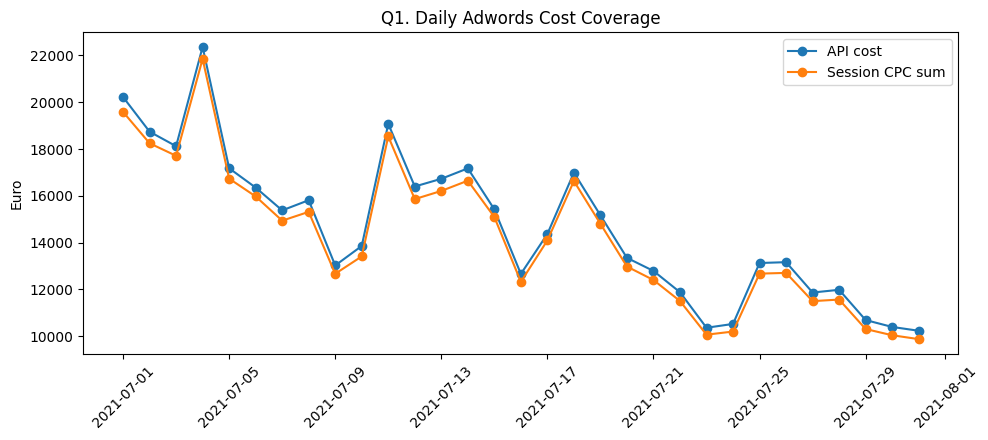

In [9]:
q1_daily = q1.groupby("event_date", as_index=False)[["api_cost", "session_cost", "api_clicks", "session_rows"]].sum()
q1_daily["event_date"] = pd.to_datetime(q1_daily["event_date"])


plt.figure(figsize=(10, 4.5))
plt.plot(q1_daily["event_date"], q1_daily["api_cost"], marker="o", label="API cost")
plt.plot(q1_daily["event_date"], q1_daily["session_cost"], marker="o", label="Session CPC sum")
plt.title("Q1. Daily Adwords Cost Coverage")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

API cost is generally close to session cost overall, but a few campaign/day combinations show noticeable gaps.

### The campaigns with largest cost gaps:

In [10]:
q1.groupby("campaign_id").sum().sort_values("cost_gap", ascending=False).head(15)["cost_gap"]

campaign_id
campaign_id_79     11756.158
campaign_id_97       254.480
campaign_id_121      174.830
campaign_id_73       153.737
campaign_id_94        81.009
campaign_id_52        80.553
campaign_id_35        75.733
campaign_id_156       53.191
campaign_id_5         48.887
campaign_id_7         30.274
campaign_id_3         23.182
campaign_id_22        21.720
campaign_id_147       20.676
campaign_id_96        19.811
campaign_id_64        15.160
Name: cost_gap, dtype: float64

         campaign_id   cost_gap  click_gap
94    campaign_id_79  11756.158       2342
107   campaign_id_97    254.480        272
13   campaign_id_121    174.830        246
89    campaign_id_73    153.737        855
104   campaign_id_94     81.009          6
69    campaign_id_52     80.553        835
57    campaign_id_35     75.733        482
37   campaign_id_156     53.191         18
66     campaign_id_5     48.887         41
86     campaign_id_7     30.274          1


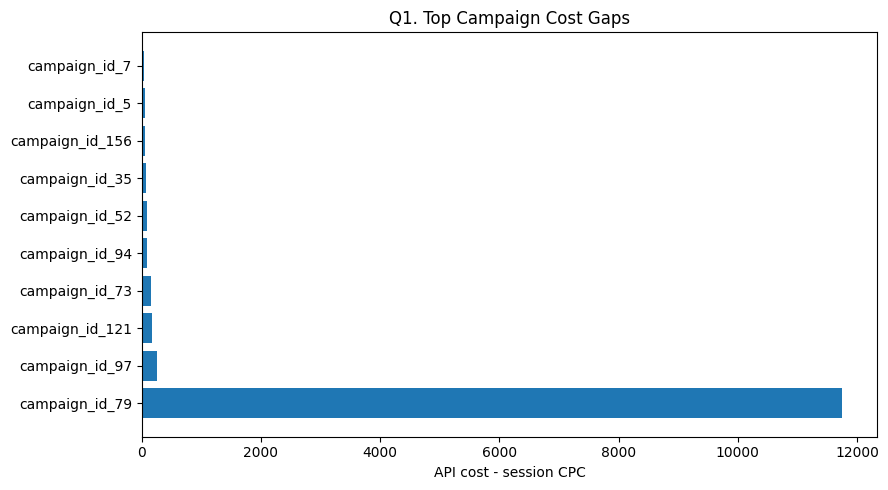

In [11]:
top_campaigns = q1.groupby("campaign_id")[["cost_gap", "click_gap"]].sum().reset_index().sort_values("cost_gap", ascending=False).head(10)
print(top_campaigns)
plt.figure(figsize=(9, 5))
plt.barh(top_campaigns["campaign_id"], top_campaigns["cost_gap"])
plt.title("Q1. Top Campaign Cost Gaps")
plt.xlabel("API cost - session CPC")
plt.tight_layout()
plt.show()

## Looking for issues

### Why `campaign_id_79` has such a large gap?

In [12]:
q1[q1["campaign_id"] == "campaign_id_79"]["session_cost"].sum()

np.float64(0.0)

Since the session cost for this specific campaign is 0, there must be something wrong with this one. <br>
We can consider it as an outlier.

### Are there any campaigns in 'api_adwords_costs' table which don't show up in session_sources?

In [13]:
campaign_issues = pd.read_sql_query(
    """
    WITH sess AS (
        SELECT
            campaign_id,
            COUNT(*) AS session_rows,
            SUM(cpc) AS session_cost
        FROM session_sources
        GROUP BY campaign_id
    ),
    api AS (
        SELECT
            campaign_id,
            SUM(cost) AS api_cost,
            SUM(clicks) AS api_clicks
        FROM api_adwords_costs
        GROUP BY campaign_id
    )
    SELECT
        a.campaign_id,
        a.api_cost,
        a.api_clicks,
        COALESCE(s.session_rows, 0) AS session_rows,
        COALESCE(s.session_cost, 0) AS session_cost,
        ROUND(a.api_cost - COALESCE(s.session_cost, 0), 2) AS cost_gap,
        a.api_clicks - COALESCE(s.session_rows, 0) AS click_gap
    FROM api a
    LEFT JOIN sess s
        ON a.campaign_id = s.campaign_id
    ORDER BY ABS(a.api_cost - COALESCE(s.session_cost, 0)) DESC
    """
, conn)

campaign_issues.head(10)


,campaign_id,api_cost,api_clicks,session_rows,session_cost,cost_gap,click_gap
0,campaign_id_79,11756.158,23269,20927,0.000,11756.16,2342
1,campaign_id_97,254.480,272,0,0.000,254.48,272
2,campaign_id_121,174.830,246,0,0.000,174.83,246
3,campaign_id_73,5226.558,2094,1264,5072.821,153.74,830
4,campaign_id_94,121.749,27,21,40.740,81.01,6
5,campaign_id_52,12532.689,3441,2736,12452.136,80.55,705
6,campaign_id_35,7219.965,2472,1990,7144.232,75.73,482
7,campaign_id_156,144.014,48,30,90.823,53.19,18
8,campaign_id_5,760.599,292,251,711.712,48.89,41
9,campaign_id_7,368.986,135,135,338.712,30.27,0


In [14]:
missing_campaigns = campaign_issues[campaign_issues.session_rows == 0]["campaign_id"].values.tolist()
print(f"The following campaigns are missing in session_sources: {missing_campaigns}")

The following campaigns are missing in session_sources: ['campaign_id_97', 'campaign_id_121']


### Recompute the coverage after excluding the three suspicious campaigns: <br>
- The one outlier: `campaign_id_79`
- Two missing campaigns: `campaign_id_97`, `campaign_id_121`

In [15]:
suspicious_campaigns = ["campaign_id_79", "campaign_id_97", "campaign_id_121"]
q1_clean = q1[~q1["campaign_id"].isin(suspicious_campaigns)]

api_cost_total_clean = q1_clean["api_cost"].sum()
session_cost_total_clean = q1_clean["session_cost"].sum()
api_clicks_total_clean = q1_clean["api_clicks"].sum()
session_rows_total_clean = q1_clean["session_rows"].sum()

print(f"Total API cost:      {api_cost_total_clean:,.2f}")
print(f"Total session cost:  {session_cost_total_clean:,.2f}")
print(f"Cost gap:            {api_cost_total_clean - session_cost_total_clean:,.2f}")
print(f"Cost coverage %:     {session_cost_total_clean / api_cost_total_clean * 100:.2f}%")
print(f"Click coverage %:    {session_rows_total_clean / api_clicks_total_clean * 100:.2f}%")

Total API cost:      443,214.34
Total session cost:  442,453.33
Cost gap:            761.01
Cost coverage %:     99.83%
Click coverage %:    93.41%


### Let's re-check the change visually

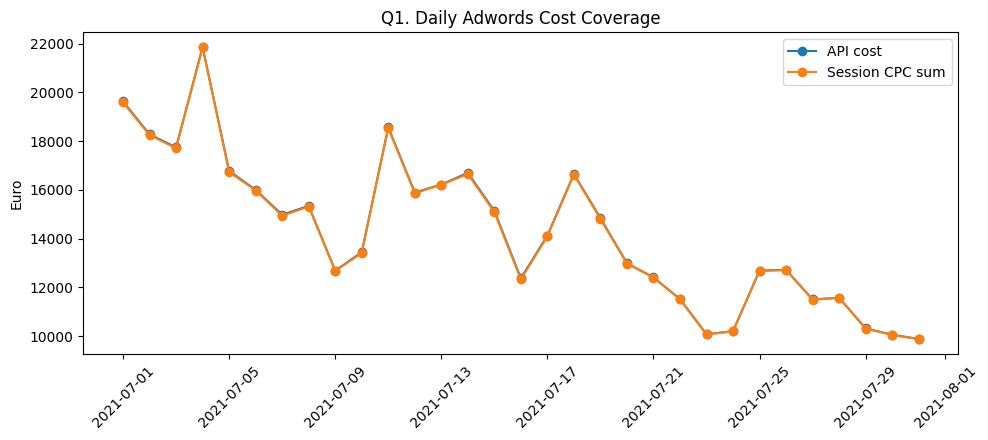

In [16]:
q1_daily_clean = q1_clean.groupby("event_date", as_index=False)[["api_cost", "session_cost", "api_clicks", "session_rows"]].sum()
q1_daily_clean["event_date"] = pd.to_datetime(q1_daily_clean["event_date"])


plt.figure(figsize=(10, 4.5))
plt.plot(q1_daily_clean["event_date"], q1_daily_clean["api_cost"], marker="o", label="API cost")
plt.plot(q1_daily_clean["event_date"], q1_daily_clean["session_cost"], marker="o", label="Session CPC sum")
plt.title("Q1. Daily Adwords Cost Coverage")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Evidently, the three suspicious campaigns were responsible for most of the problems. <br>

**Simple conclusion for Q1**

- Overall coverage is high but not complete.
- The main problem campaign is **`campaign_id_79`**.
- **`campaign_id_97`** and **`campaign_id_121`** appear in API cost data but not in session data.
- A practical assumption in this comparison is that **session rows are the closest available counterpart to API clicks**.


# Q2) Are the conversions in `conversions` stable over time? Any pattern?

### What will be done:
I look at conversions by day and ask:

- do counts move smoothly or abruptly?
- do frontend and backend stay close?
- is there a visible spike or drop?

In [17]:
conv_daily = pd.read_sql_query(
    """
    SELECT
        conv_date,
        COUNT(*) AS conversions,
        SUM(revenue) AS total_revenue,
        AVG(revenue) AS avg_revenue
    FROM conversions
    GROUP BY conv_date
    ORDER BY conv_date
    """
, conn)

conv_daily


,conv_date,conversions,total_revenue,avg_revenue
0,2021-07-15,968,48140.04,49.731446
1,2021-07-16,809,38388.89,47.452274
2,2021-07-17,691,34721.01,50.247482
3,2021-07-18,1370,74555.65,54.420182
4,2021-07-19,842,41764.69,49.601770
5,2021-07-20,764,37678.05,49.316819
6,2021-07-21,783,37516.15,47.913346
7,2021-07-22,830,38041.52,45.833157
8,2021-07-23,743,36188.87,48.706420
9,2021-07-24,682,31101.09,45.602771


In [18]:
conv_compare_daily = pd.read_sql_query(
    """
    WITH c AS (
        SELECT conv_date, COUNT(*) AS cnt, SUM(revenue) AS rev
        FROM conversions
        GROUP BY conv_date
    ),
    b AS (
        SELECT conv_date, COUNT(*) AS cnt, SUM(revenue) AS rev
        FROM conversions_backend
        GROUP BY conv_date
    )
    SELECT
        b.conv_date,
        b.cnt AS backend_cnt,
        c.cnt AS front_cnt,
        b.rev AS backend_rev,
        c.rev AS front_rev,
        b.cnt - COALESCE(c.cnt, 0) AS cnt_gap,
        ROUND(b.rev - COALESCE(c.rev, 0), 2) AS rev_gap
    FROM b
    LEFT JOIN c
        ON b.conv_date = c.conv_date
    ORDER BY b.conv_date
    """
, conn)

conv_compare_daily


,conv_date,backend_cnt,front_cnt,backend_rev,front_rev,cnt_gap,rev_gap
0,2021-07-15,986,968,49637.75,48140.04,18,1497.71
1,2021-07-16,830,809,40003.75,38388.89,21,1614.86
2,2021-07-17,704,691,36164.40,34721.01,13,1443.39
3,2021-07-18,1401,1370,77011.74,74555.65,31,2456.09
4,2021-07-19,853,842,43024.79,41764.69,11,1260.10
5,2021-07-20,780,764,39020.80,37678.05,16,1342.75
6,2021-07-21,796,783,38329.93,37516.15,13,813.78
7,2021-07-22,851,830,39924.15,38041.52,21,1882.63
8,2021-07-23,759,743,37050.82,36188.87,16,861.95
9,2021-07-24,694,682,31886.57,31101.09,12,785.48


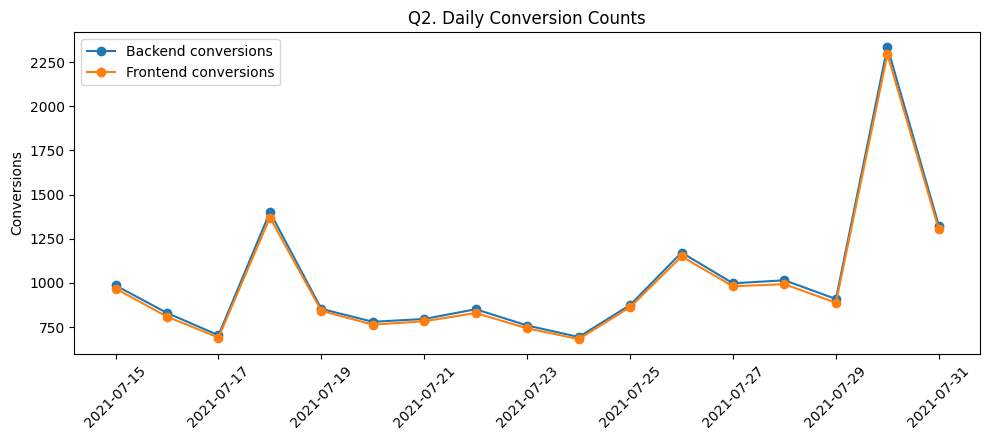

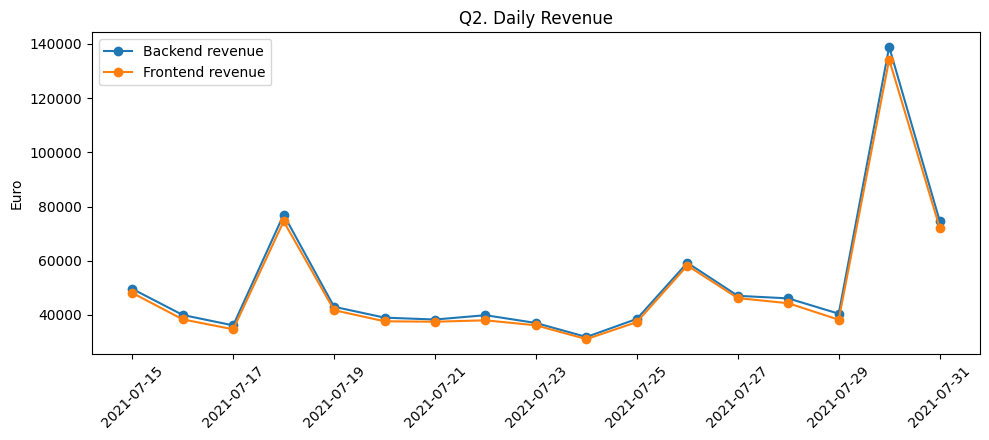

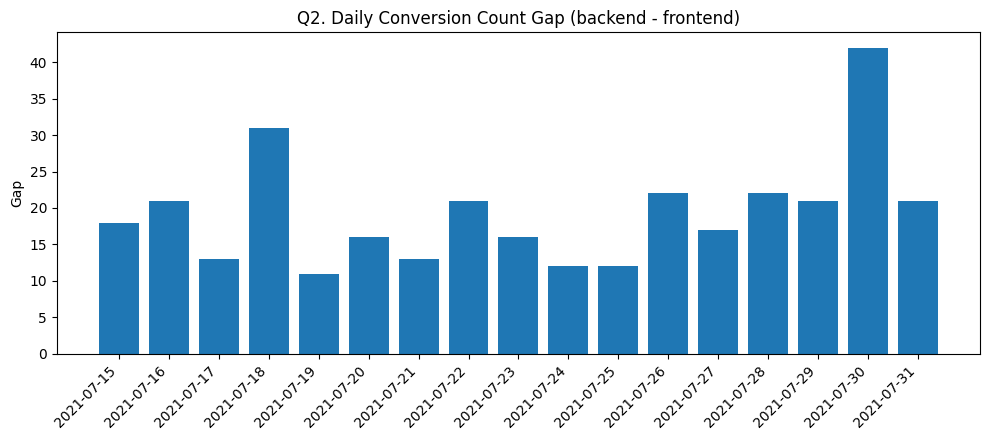

In [19]:
tmp = conv_compare_daily.copy()
tmp["conv_date"] = pd.to_datetime(tmp["conv_date"])

plt.figure(figsize=(10, 4.5))
plt.plot(tmp["conv_date"], tmp["backend_cnt"], marker="o", label="Backend conversions")
plt.plot(tmp["conv_date"], tmp["front_cnt"], marker="o", label="Frontend conversions")
plt.title("Q2. Daily Conversion Counts")
plt.ylabel("Conversions")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(tmp["conv_date"], tmp["backend_rev"], marker="o", label="Backend revenue")
plt.plot(tmp["conv_date"], tmp["front_rev"], marker="o", label="Frontend revenue")
plt.title("Q2. Daily Revenue")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.bar(tmp["conv_date"].dt.strftime("%Y-%m-%d"), tmp["cnt_gap"])
plt.title("Q2. Daily Conversion Count Gap (backend - frontend)")
plt.ylabel("Gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Q2 stability statistics:


,series,mean,std,cv
0,backend_cnt,1016.647059,395.437723,0.388963
1,front_cnt,997.294118,388.430458,0.389484
2,backend_rev,51602.991765,25895.039198,0.501813
3,front_rev,49947.215882,25057.236520,0.501674


Q2 spike candidates from backend counts:


,conv_date,backend_cnt,front_cnt,cnt_gap,backend_rev,front_rev,rev_gap,backend_cnt_robust_z
3,2021-07-18,1401,1370,31,77011.74,74555.65,2456.09,3.058509
15,2021-07-30,2336,2294,42,138900.90,134246.42,4654.48,8.495211


Q2 weekday pattern summary:


,weekday,days,avg_backend_cnt,avg_front_cnt,avg_cnt_gap,avg_backend_rev,avg_front_rev,avg_rev_gap,avg_front_to_backend_cnt_ratio,avg_front_to_backend_rev_ratio
1,Monday,2,1012.500000,996.000000,16.500000,51144.220000,50010.275000,1133.945000,0.984167,0.976854
5,Tuesday,2,889.000000,872.500000,16.500000,43047.045000,41957.650000,1089.395000,0.981227,0.973914
6,Wednesday,2,905.500000,888.000000,17.500000,42229.990000,40929.985000,1300.005000,0.980997,0.970024
4,Thursday,3,915.333333,895.333333,20.000000,43346.423333,41481.126667,1865.296667,0.977988,0.955979
0,Friday,3,1308.333333,1282.000000,26.333333,71985.156667,69608.060000,2377.096667,0.978546,0.967620
2,Saturday,3,907.333333,892.000000,15.333333,47613.313333,46032.063333,1581.250000,0.982794,0.967276
3,Sunday,2,1138.000000,1116.500000,21.500000,57786.835000,55971.550000,1815.285000,0.982079,0.968825


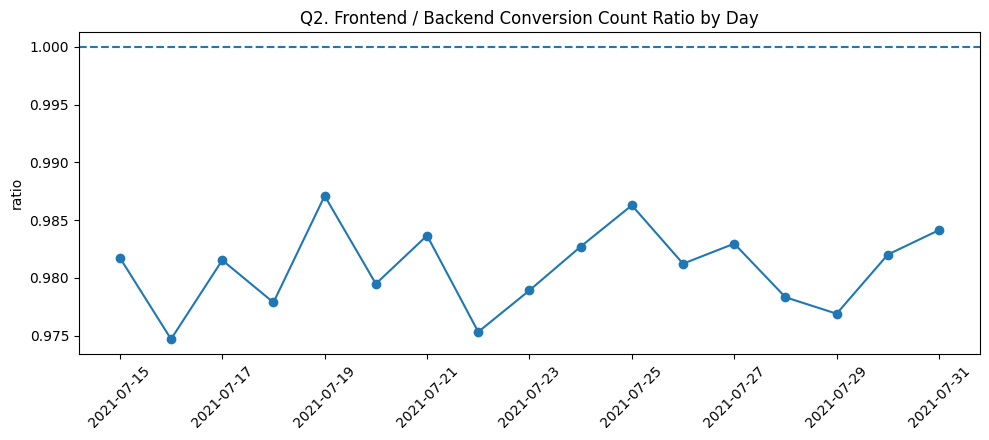

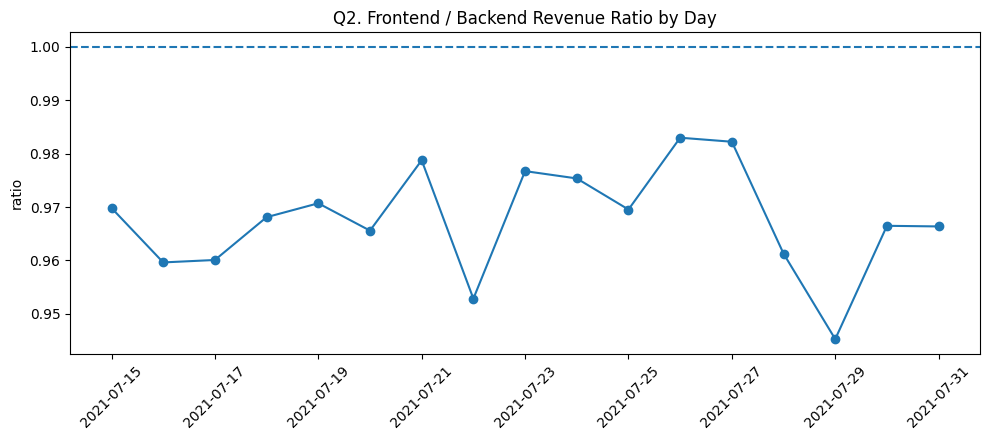

Q2 takeaway:
- Across 17 observed days, daily conversion counts are fairly stable overall, with limited day-to-day volatility.
- Frontend conversion counts are below backend on 17/17 days.
- Frontend revenue is below backend on 17/17 days.
- This points to a systematic frontend under-recording pattern rather than a few isolated bad days.
- Spike candidates based on backend counts are listed above.


In [ ]:
q2_daily = conv_compare_daily.copy()
q2_daily["conv_date"] = pd.to_datetime(q2_daily["conv_date"])
q2_daily = q2_daily.sort_values("conv_date").reset_index(drop=True)

num_cols = ["backend_cnt", "front_cnt", "backend_rev", "front_rev", "cnt_gap", "rev_gap"]
for col in num_cols:
    q2_daily[col] = pd.to_numeric(q2_daily[col], errors="coerce")

q2_daily["weekday"] = q2_daily["conv_date"].dt.day_name()

# Ratios: useful for showing whether frontend is systematically below backend
q2_daily["front_to_backend_cnt_ratio"] = np.where(
    q2_daily["backend_cnt"] > 0,
    q2_daily["front_cnt"] / q2_daily["backend_cnt"],
    np.nan
)

q2_daily["front_to_backend_rev_ratio"] = np.where(
    q2_daily["backend_rev"] > 0,
    q2_daily["front_rev"] / q2_daily["backend_rev"],
    np.nan
)

q2_daily["cnt_gap_pct_of_backend"] = np.where(
    q2_daily["backend_cnt"] > 0,
    q2_daily["cnt_gap"] / q2_daily["backend_cnt"],
    np.nan
)

q2_daily["rev_gap_pct_of_backend"] = np.where(
    q2_daily["backend_rev"] > 0,
    q2_daily["rev_gap"] / q2_daily["backend_rev"],
    np.nan
)

# Day-over-day changes on the backend truth
q2_daily["backend_cnt_dod_pct"] = q2_daily["backend_cnt"].pct_change()
q2_daily["backend_rev_dod_pct"] = q2_daily["backend_rev"].pct_change()

# Robust spike detection on backend counts
median_cnt = q2_daily["backend_cnt"].median()
mad_cnt = np.median(np.abs(q2_daily["backend_cnt"] - median_cnt))

if mad_cnt == 0:
    q2_daily["backend_cnt_robust_z"] = 0.0
else:
    q2_daily["backend_cnt_robust_z"] = 0.6745 * (q2_daily["backend_cnt"] - median_cnt) / mad_cnt

q2_spikes = q2_daily.loc[
    q2_daily["backend_cnt_robust_z"].abs() >= 3,
    [
        "conv_date",
        "backend_cnt",
        "front_cnt",
        "cnt_gap",
        "backend_rev",
        "front_rev",
        "rev_gap",
        "backend_cnt_robust_z",
    ]
].copy()

q2_stability_stats = pd.DataFrame({
    "series": ["backend_cnt", "front_cnt", "backend_rev", "front_rev"],
    "mean": [
        q2_daily["backend_cnt"].mean(),
        q2_daily["front_cnt"].mean(),
        q2_daily["backend_rev"].mean(),
        q2_daily["front_rev"].mean(),
    ],
    "std": [
        q2_daily["backend_cnt"].std(),
        q2_daily["front_cnt"].std(),
        q2_daily["backend_rev"].std(),
        q2_daily["front_rev"].std(),
    ],
})

q2_stability_stats["cv"] = q2_stability_stats["std"] / q2_stability_stats["mean"]

print("Q2 stability statistics:")
display(q2_stability_stats)

print("Q2 spike candidates from backend counts:")
display(q2_spikes if len(q2_spikes) > 0 else pd.DataFrame({"message": ["No spike candidates at robust z >= 3"]}))

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

q2_weekday = (
    q2_daily
    .groupby("weekday", as_index=False)
    .agg(
        days=("conv_date", "count"),
        avg_backend_cnt=("backend_cnt", "mean"),
        avg_front_cnt=("front_cnt", "mean"),
        avg_cnt_gap=("cnt_gap", "mean"),
        avg_backend_rev=("backend_rev", "mean"),
        avg_front_rev=("front_rev", "mean"),
        avg_rev_gap=("rev_gap", "mean"),
        avg_front_to_backend_cnt_ratio=("front_to_backend_cnt_ratio", "mean"),
        avg_front_to_backend_rev_ratio=("front_to_backend_rev_ratio", "mean"),
    )
)

q2_weekday["weekday"] = pd.Categorical(q2_weekday["weekday"], categories=weekday_order, ordered=True)
q2_weekday = q2_weekday.sort_values("weekday")

print("Q2 weekday pattern summary:")
display(q2_weekday)


plt.figure(figsize=(10, 4.5))
plt.plot(q2_daily["conv_date"], q2_daily["front_to_backend_cnt_ratio"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.title("Q2. Frontend / Backend Conversion Count Ratio by Day")
plt.ylabel("ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(q2_daily["conv_date"], q2_daily["front_to_backend_rev_ratio"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.title("Q2. Frontend / Backend Revenue Ratio by Day")
plt.ylabel("ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

under_count_days = int((q2_daily["front_cnt"] < q2_daily["backend_cnt"]).sum())
under_rev_days = int((q2_daily["front_rev"] < q2_daily["backend_rev"]).sum())
total_days = int(len(q2_daily))

print(
    f"""
Q2 takeaway:
- Across {total_days} observed days, daily conversion counts are fairly stable overall, with limited day-to-day volatility.
- Frontend conversion counts are below backend on {under_count_days}/{total_days} days.
- Frontend revenue is below backend on {under_rev_days}/{total_days} days.
- This points to a systematic frontend under-recording pattern rather than a few isolated bad days.
- Spike candidates based on backend counts are listed above.
""".strip()
)

# Q3) Double check `conversions` with `conversions_backend`

### What should be done
This is a direct reconciliation test. For each `conv_id`, ask:

- is it present in both tables?
- if yes, do `user_id`, `conv_date`, `market`, and `revenue` match?

According to the task states the `conversions_backend` is the **true** table.


### Is there any missing conversions?

In [20]:
missing_in_front = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions_backend b
    LEFT JOIN conversions c
        ON b.conv_id = c.conv_id
    WHERE c.conv_id IS NULL
    """
, conn)

missing_in_back = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions c
    LEFT JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    WHERE b.conv_id IS NULL
    """
, conn)

print("Missing in conversions:", missing_in_front.iloc[0, 0])
print("Missing in backend:", missing_in_back.iloc[0, 0])


Missing in conversions: 345
Missing in backend: 0


### Count number of mismatch conversions

In [21]:
mismatch_summary = pd.read_sql_query(
    """
    SELECT
        SUM(CASE WHEN c.user_id != b.user_id THEN 1 ELSE 0 END) AS user_mismatch,
        SUM(CASE WHEN c.conv_date != b.conv_date THEN 1 ELSE 0 END) AS date_mismatch,
        SUM(CASE WHEN c.market != b.market THEN 1 ELSE 0 END) AS market_mismatch,
        SUM(CASE WHEN ABS(c.revenue - b.revenue) > 1e-9 THEN 1 ELSE 0 END) AS revenue_mismatch
    FROM conversions c
    JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    """
, conn)

mismatch_summary


,user_mismatch,date_mismatch,market_mismatch,revenue_mismatch
0,16,0,0,172


In [ ]:
bad_conversions = pd.read_sql_query(
    """
    SELECT
        c.conv_id,
        c.user_id AS c_user_id,
        b.user_id AS b_user_id,
        c.conv_date AS c_conv_date,
        b.conv_date AS b_conv_date,
        c.market AS c_market,
        b.market AS b_market,
        c.revenue AS c_revenue,
        b.revenue AS b_revenue

    FROM conversions c

    JOIN conversions_backend b ON c.conv_id = b.conv_id

    WHERE c.user_id != b.user_id
        OR c.conv_date != b.conv_date
        OR c.market != b.market
        OR ABS(c.revenue - b.revenue) > 1e-9

    ORDER BY c.conv_id
    """
, conn)

bad_conversions.head(20)

,conv_id,c_user_id,b_user_id,c_conv_date,b_conv_date,c_market,b_market,c_revenue,b_revenue
0,conv_id_10041,user_id_1147740,user_id_1147740,2021-07-30,2021-07-30,NL,NL,0.00,51.56
1,conv_id_10055,user_id_815190,user_id_815190,2021-07-28,2021-07-28,GB,GB,0.00,7.50
2,conv_id_10449,user_id_665055,user_id_665055,2021-07-21,2021-07-21,DE,DE,0.00,130.12
3,conv_id_10480,user_id_662105,user_id_662105,2021-07-30,2021-07-30,NL,NL,0.00,42.97
4,conv_id_10545,user_id_7939,user_id_7939,2021-07-30,2021-07-30,NL,NL,0.00,34.38
5,conv_id_1056,user_id_484328,user_id_484328,2021-07-15,2021-07-15,GB,GB,0.00,15.79
6,conv_id_10730,user_id_470610,user_id_470610,2021-07-30,2021-07-30,GB,GB,0.00,116.00
7,conv_id_10765,user_id_1394,user_id_1394,2021-07-27,2021-07-27,DE,DE,0.00,34.03
8,conv_id_10781,user_id_808017,user_id_808017,2021-07-22,2021-07-22,GB,GB,0.00,253.56
9,conv_id_10826,user_id_197806,user_id_172209,2021-07-30,2021-07-30,NL,NL,44.96,44.96


We can see that the difference is between revenue values.

### How is revenue difference distributed?

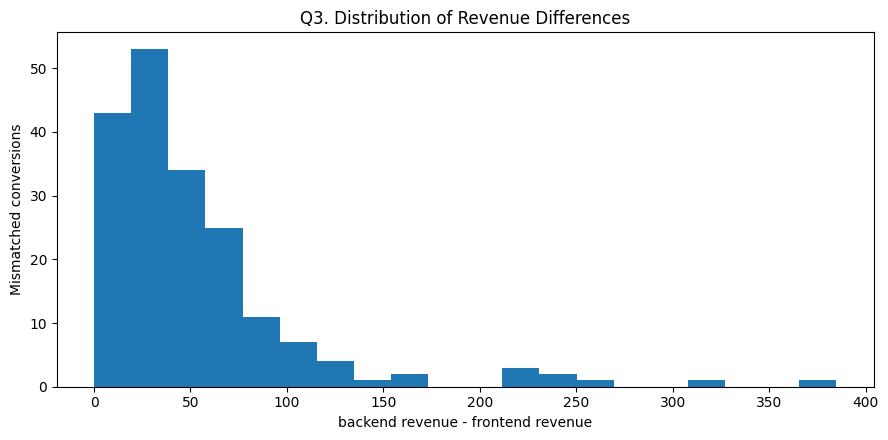

In [23]:
bad_conversions["revenue_diff"] = bad_conversions["b_revenue"] - bad_conversions["c_revenue"]
plt.figure(figsize=(9, 4.5))
plt.hist(bad_conversions["revenue_diff"], bins=20)
plt.title("Q3. Distribution of Revenue Differences")
plt.xlabel("backend revenue - frontend revenue")
plt.ylabel("Mismatched conversions")
plt.tight_layout()
plt.show()

The revenue-gap distribution is strongly right-skewed: most affected conversions have relatively small to moderate gaps, with fewer large gaps. Since all revenue mismatches are cases where frontend revenue is zero and backend revenue is positive, this distribution reflects the backend revenue of those affected conversions.

### How many conversions are recorded with zero revenue in front-end and non-zero in backend?

In [24]:
zero_revenue_bug = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions c
    JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    WHERE c.revenue = 0
      AND b.revenue > 0
    """
, conn)

print(f"Zero-revenue conversions in frontend that are positive in backend: {zero_revenue_bug.iloc[0, 0]}")


Zero-revenue conversions in frontend that are positive in backend: 172


### A summary of all findings:

In [25]:
issue_counts = pd.DataFrame({
    "Issue": [
        "Missing in frontend",
        "Missing in backend",
        "Revenue mismatch",
        "User mismatch",
        "Date mismatch",
        "Market mismatch",
    ],
    "Count": [
        int(missing_in_front.iloc[0, 0]),
        int(missing_in_back.iloc[0, 0]),
        int(mismatch_summary.loc[0, "revenue_mismatch"]),
        int(mismatch_summary.loc[0, "user_mismatch"]),
        int(mismatch_summary.loc[0, "date_mismatch"]),
        int(mismatch_summary.loc[0, "market_mismatch"]),
    ]
})

issue_counts

,Issue,Count
0,Missing in frontend,345
1,Missing in backend,0
2,Revenue mismatch,172
3,User mismatch,16
4,Date mismatch,0
5,Market mismatch,0


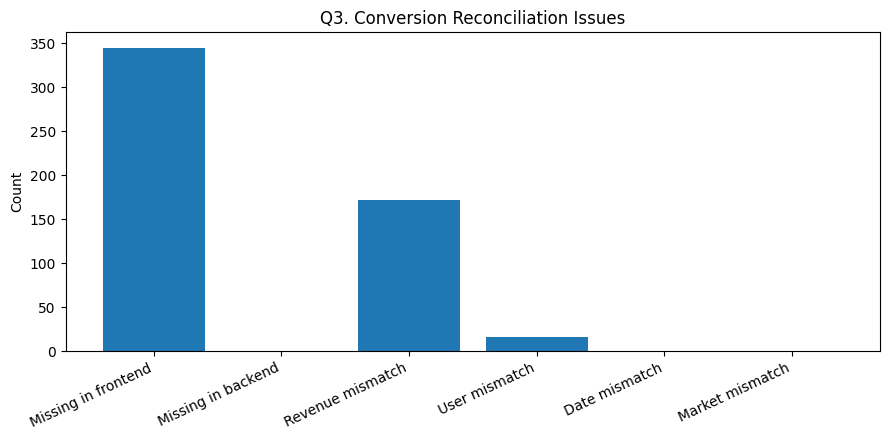

In [26]:
plt.figure(figsize=(9, 4.5))
plt.bar(issue_counts["Issue"], issue_counts["Count"])
plt.title("Q3. Conversion Reconciliation Issues")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Simple conclusion for Q3**

- `conversions_backend` is the source of truth.
- There are **345** conversions missing from the frontend table.
- There are **172** revenue mismatches and **16** user mismatches.
- All revenue mismatches follow the same pattern: **frontend revenue = 0, backend revenue > 0**.


# Q4) Are attribution results consistent? (does each conversion have a sensible set of sessions attached to it?)
### What should be done
For each conversion, attribution says which sessions belong to the customer journey and how much credit each session gets through `ihc` (If the sum of `ihc` for a conversion is materially different from 1, the attribution weights are inconsistent).

A valid attribution result should satisfy at least these checks:
- the sum of `ihc` for one conversion should be close (I say close and not equal to compensate for numerical errors) to **1**
- the sessions should belong to the **same user** as the conversion
- the conversion referenced in attribution should exist

### Note 
For the cross-user check below, here I use **`conversions_backend`** rather than `conversions`, because the backend table is the source of truth.


In [82]:
ihc_check = pd.read_sql_query(
    """
    SELECT
        conv_id,
        COUNT(*) AS n_sessions,
        SUM(ihc) AS ihc_sum,
        MIN(ihc) AS min_ihc,
        MAX(ihc) AS max_ihc

    FROM attribution_customer_journey
    
    GROUP BY conv_id
    ORDER BY conv_id
    """
, conn)

ihc_check.head()


,conv_id,n_sessions,ihc_sum,min_ihc,max_ihc
0,conv_id_1,1,1.0,1.00000,1.000000
1,conv_id_10,10,1.0,0.00000,0.333333
2,conv_id_100,2,1.0,0.50000,0.500000
3,conv_id_1000,2,1.0,0.00000,1.000000
4,conv_id_10002,2,1.0,0.44808,0.551920


### If abs(sum(ihc) - 1) > 0.001 for a conversion, the attribution weights are inconsistent.

In [83]:
bad_ihc = ihc_check[(ihc_check["ihc_sum"] - 1).abs() > 0.001].copy()

print("Conversions with bad ihc sum:", len(bad_ihc))
bad_ihc.sort_values(by="ihc_sum").head(20)


Conversions with bad ihc sum: 158


,conv_id,n_sessions,ihc_sum,min_ihc,max_ihc
4296,conv_id_404,1,0.000000,0.000000,0.000000
4901,conv_id_5356,1,0.000000,0.000000,0.000000
5380,conv_id_642,1,0.000000,0.000000,0.000000
2263,conv_id_15073,4,0.000000,0.000000,0.000000
428,conv_id_1091,1,0.000000,0.000000,0.000000
278,conv_id_10614,1,0.000000,0.000000,0.000000
2284,conv_id_15124,1,0.333342,0.333342,0.333342
6380,conv_id_8683,5,0.333517,0.000000,0.333517
6472,conv_id_8887,1,0.333610,0.333610,0.333610
6975,conv_id_9955,1,0.333617,0.333617,0.333617


### How is IHC distributed?

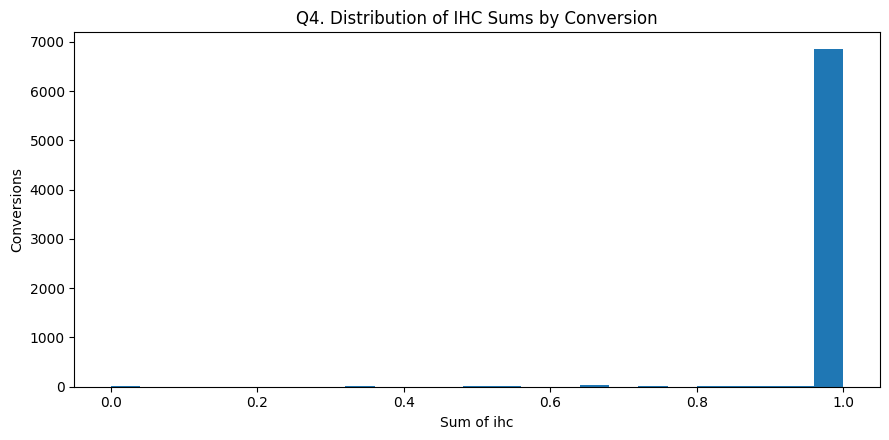

In [84]:
plt.figure(figsize=(9, 4.5))
plt.hist(ihc_check["ihc_sum"], bins=25)
plt.title("Q4. Distribution of IHC Sums by Conversion")
plt.xlabel("Sum of ihc")
plt.ylabel("Conversions")
plt.tight_layout()
plt.show()

### Row-level ihc validity on `ihc`

In [95]:
ihc_row_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT conv_id) AS bad_conversions,
        COALESCE(SUM(CASE WHEN ihc IS NULL THEN 1 ELSE 0 END), 0) AS null_ihc_rows,
        COALESCE(SUM(CASE WHEN ihc < 0 THEN 1 ELSE 0 END), 0) AS negative_ihc_rows,
        COALESCE(SUM(CASE WHEN ihc > 1 THEN 1 ELSE 0 END), 0) AS ihc_gt_1_rows
    FROM attribution_customer_journey
    WHERE ihc IS NULL
       OR ihc < 0
       OR ihc > 1
    """
, conn)

print("Q4 row-level ihc validity:")
display(ihc_row_check)

Q4 row-level ihc validity:


,bad_rows,bad_conversions,null_ihc_rows,negative_ihc_rows,ihc_gt_1_rows
0,6,6,0,0,6


### Duplicate session_id inside the same conversion journey

In [100]:
duplicate_attr_pairs = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS duplicated_conv_session_pairs,
        COUNT(DISTINCT conv_id) AS affected_conversions
    FROM (
        SELECT
            conv_id,
            session_id,
            COUNT(*) AS n_rows
        FROM attribution_customer_journey
        GROUP BY conv_id, session_id
        HAVING COUNT(*) > 1
    ) d
    """
, conn)

print("Q4 duplicate session rows inside a journey:")
display(duplicate_attr_pairs)

Q4 duplicate session rows inside a journey:


,duplicated_conv_session_pairs,affected_conversions
0,0,0


### 3) Temporal check: sessions should not happen after the conversion date <br>
 Important limitation: conversion tables only have conv_date, not conv_time. <br>
 So this checks for sessions on strictly later dates, which is still a strong sanity test.

In [101]:
attr_future_sessions = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.conv_id) AS bad_conversions

    FROM attribution_customer_journey a
    
    JOIN conversions_backend c ON a.conv_id = c.conv_id
    JOIN session_sources s ON a.session_id = s.session_id

    WHERE DATE(s.event_date) > DATE(c.conv_date)
    """
, conn)

print("Q4 future sessions after conversion date:")
display(attr_future_sessions)


Q4 future sessions after conversion date:


,bad_rows,bad_conversions
0,0,0


### Are there cross-user journeys, i.e. cases where the backend conversion user_id differs from the attributed session user_id?

In [ ]:
cross_user_attr = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.conv_id) AS bad_conversions

    FROM attribution_customer_journey a

    JOIN conversions_backend c ON a.conv_id = c.conv_id
    JOIN session_sources s ON a.session_id = s.session_id

    WHERE c.user_id != s.user_id
    """
, conn)

bad_attr_rows = cross_user_attr["bad_rows"].values.tolist()[0]
bad_conversions_count = cross_user_attr["bad_conversions"].values.tolist()[0]


print(f"Number of attribution rows with mismatched user_id between backend conversion and session: {bad_attr_rows:,}")
print(f"Number of conversions affected by user_id mismatch between backend conversion and session: {bad_conversions_count:,}")

Number of attribution rows with mismatched user_id between backend conversion and session: 7,262
Number of conversions affected by user_id mismatch between backend conversion and session: 2,584


### Is there any row with missing `session_id`?

In [86]:
attr_missing_session = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.session_id) AS bad_session_ids,
        COUNT(DISTINCT a.conv_id) AS affected_conversions

    FROM attribution_customer_journey a
    LEFT JOIN session_sources s ON a.session_id = s.session_id
    WHERE s.session_id IS NULL
    """,
    conn
)

attr_missing_session

,bad_rows,bad_session_ids,affected_conversions
0,0,0,0


### Are there rows in `attribution_customer_journey` which do not correspond to any row in `conversions_backend`?

In [89]:
attr_missing_conv = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.conv_id) AS bad_conv_ids

    FROM attribution_customer_journey a

    LEFT JOIN conversions_backend c ON a.conv_id = c.conv_id
    WHERE c.conv_id IS NULL
    """
, conn)

bad_rows = attr_missing_conv["bad_rows"].values.tolist()[0]
bad_conversion_ids = attr_missing_conv["bad_conv_ids"].values.tolist()[0]

print(f"Number of ROWS in attributions table with no corresponding conversion in backend: {bad_rows:,}")
print(f"Number of CONVERSIONS in attributions table with no corresponding conversion in backend: {bad_conversion_ids:,}")

Number of ROWS in attributions table with no corresponding conversion in backend: 0
Number of CONVERSIONS in attributions table with no corresponding conversion in backend: 0


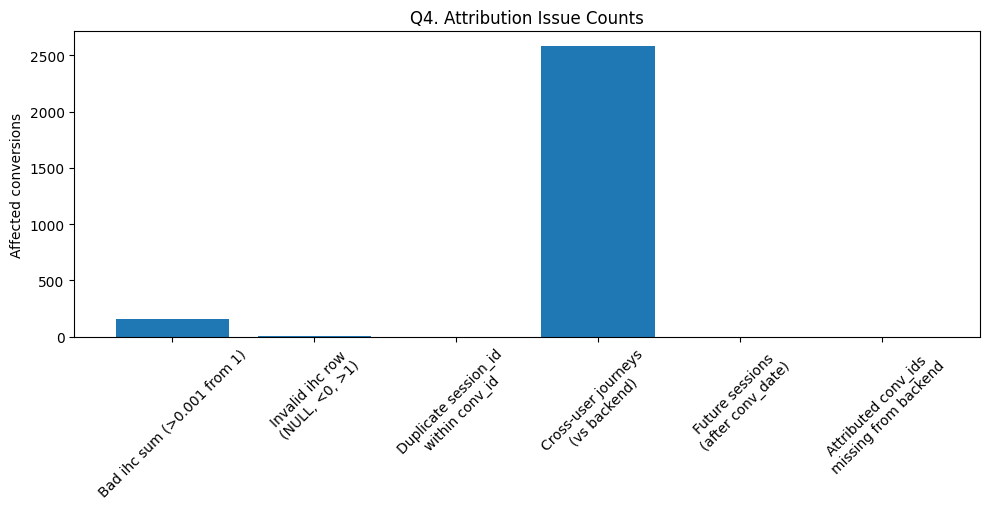

,Issue,Count
3,Cross-user journeys\n(vs backend),2584
0,Bad ihc sum (>0.001 from 1),158
1,"Invalid ihc row\n(NULL, <0, >1)",6
2,Duplicate session_id\nwithin conv_id,0
4,Future sessions\n(after conv_date),0
5,Attributed conv_ids\nmissing from backend,0


In [104]:
q4_issue_counts = pd.DataFrame({
    "Issue": [
        "Bad ihc sum (>0.001 from 1)",
        "Invalid ihc row\n(NULL, <0, >1)",
        "Duplicate session_id\nwithin conv_id",
        "Cross-user journeys\n(vs backend)",
        "Future sessions\n(after conv_date)",
        "Attributed conv_ids\nmissing from backend",
    ],
    "Count": [
        len(bad_ihc),
        int(ihc_row_check.loc[0, "bad_conversions"]),
        int(duplicate_attr_pairs.loc[0, "affected_conversions"]),
        int(cross_user_attr.loc[0, "bad_conversions"]),
        int(attr_future_sessions.loc[0, "bad_conversions"]),
        int(attr_missing_conv.loc[0, "bad_conv_ids"]),
    ]
})

plt.figure(figsize=(10, 5.2))
plt.bar(q4_issue_counts["Issue"], q4_issue_counts["Count"])
plt.title("Q4. Attribution Issue Counts")
plt.ylabel("Affected conversions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(q4_issue_counts.sort_values("Count", ascending=False))

# Q5) Bonus — Do we have a channeling issue? Are sessions per channel stable over time?

We are checking whether:
- channel labels are clean and consistent
- channel counts behave normally over time

### Are channel names consistent?

In [40]:
channel_names = pd.read_sql_query(
    """
    SELECT DISTINCT(channel_name)
    
    FROM session_sources
    """,
    conn
)

channel_names

,channel_name
0,Affiliate
1,Affiliates
2,Content Marketing
3,Direct
4,Direct Traffic
5,Display
6,Display Remarketing
7,Email
8,Google Remarketing
9,Influencers


Since there are only 28 names, we can sort them out manually.

In [41]:
channel_groups = {
    "Affiliate": [
        "Affiliate",
        "Affiliates",
    ],
    "Direct": [
        "Direct",
        "Direct Traffic",
    ],
    "SEA - Brand": [
        "SEA - Brand",
        "SEA - Branded",
    ],
    "SEA - Non-Brand": [
        "SEA - Non-Brand",
        "SEA - Non-branded",
    ],
    "Shopping - Brand": [
        "Shopping - Brand",
        "Shopping - Branded",
    ],
    "Shopping - Non-Brand": [
        "Shopping - Non Brand",
        "Shopping - Non-branded",
    ],
    "Social - Organic": [
        "Social - Organic",
        "Social Organic",
    ],
    "Social - Paid": [
        "Social - Paid",
        "Social Paid",
    ],
}

channel_mapping = {
    "Affiliate": "Affiliate",
    "Affiliates": "Affiliate",

    "Content Marketing": "Content Marketing",

    "Direct": "Direct",
    "Direct Traffic": "Direct",

    "Display": "Display",
    "Display Remarketing": "Display Remarketing",

    "Email": "Email",
    "Google Remarketing": "Google Remarketing",
    "Influencers": "Influencers",
    "Referral": "Referral",

    "SEA (no tagging)": "SEA (no tagging)",
    "SEA - Brand": "SEA - Brand",
    "SEA - Branded": "SEA - Brand",
    "SEA - Non-Brand": "SEA - Non-Brand",
    "SEA - Non-branded": "SEA - Non-Brand",

    "SEO": "SEO",

    "Shopping - Brand": "Shopping - Brand",
    "Shopping - Branded": "Shopping - Brand",
    "Shopping - Non Brand": "Shopping - Non-Brand",
    "Shopping - Non-branded": "Shopping - Non-Brand",

    "Social - Organic": "Social - Organic",
    "Social Organic": "Social - Organic",
    "Social - Paid": "Social - Paid",
    "Social Paid": "Social - Paid",
    "Social Remarketing": "Social Remarketing",

    "Video Marketing": "Video Marketing",
    "YouTube Video Ads": "YouTube Video Ads",
}

In [44]:
channel_daily_raw = pd.read_sql_query(
    """
    SELECT
        event_date,
        channel_name,
        COUNT(DISTINCT session_id) AS sessions

    FROM session_sources
    
    GROUP BY event_date, channel_name
    ORDER BY event_date, channel_name
    """,
    conn
)

channel_daily_raw["channel_name"] = channel_daily_raw["channel_name"].apply(lambda x: channel_mapping[x])
channel_daily_raw = channel_daily_raw.groupby(["event_date", "channel_name"]).agg({"sessions": sum}).reset_index()
channel_daily_raw

,event_date,channel_name,sessions
0,2021-07-01,Affiliate,1058
1,2021-07-01,Direct,10333
2,2021-07-01,Display,732
3,2021-07-01,Email,1890
4,2021-07-01,Google Remarketing,94
...,...,...,...
556,2021-07-31,Social - Organic,668
557,2021-07-31,Social - Paid,5897
558,2021-07-31,Social Remarketing,1067
559,2021-07-31,Video Marketing,5


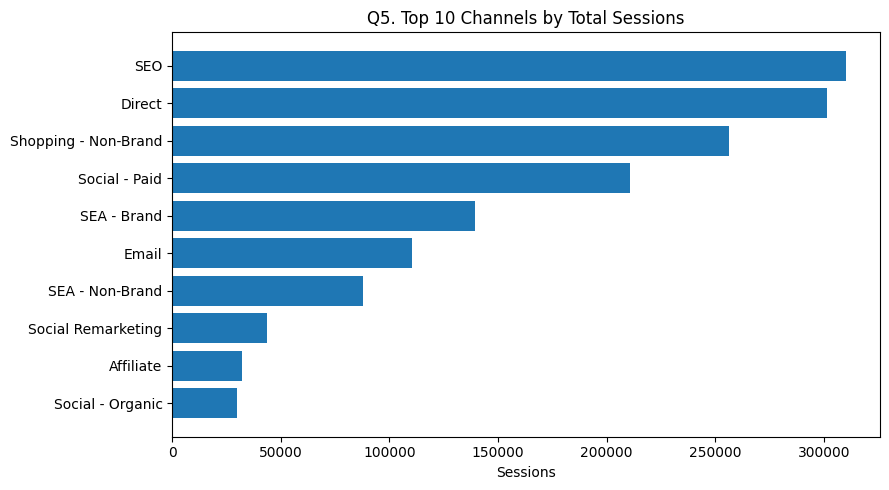

In [79]:
top_channels = (
    channel_daily_raw
    .groupby("channel_name", as_index=False)["sessions"]
    .sum()
    .sort_values("sessions", ascending=False)
    .head(10)
    .sort_values("sessions")
)

plt.figure(figsize=(9, 5))
plt.barh(top_channels["channel_name"], top_channels["sessions"])
plt.title("Q5. Top 10 Channels by Total Sessions")
plt.xlabel("Sessions")
plt.tight_layout()
plt.show()

In [47]:
channel_missing_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN channel_name IS NULL THEN 1 ELSE 0 END) AS null_channel_rows,
        SUM(CASE WHEN channel_name IS NOT NULL AND TRIM(channel_name) = '' THEN 1 ELSE 0 END) AS blank_channel_rows

    FROM session_sources
    """,
    conn
)

channel_missing_check

,total_rows,null_channel_rows,blank_channel_rows
0,1616702,0,0


### Stability check

In [60]:
channel_daily_raw["event_date"] = pd.to_datetime(channel_daily_raw["event_date"])

channel_daily = (
    channel_daily_raw
    .groupby(["event_date", "channel_name"], as_index=False)["sessions"]
    .sum()
)

channel_profile = (
    channel_daily
    .groupby("channel_name", as_index=False)["sessions"]
    .sum()
    .sort_values("sessions", ascending=False)
)

print("Channel profile:")
display(channel_profile)


Channel profile:


,channel_name,sessions
12,SEO,310277
2,Direct,301307
14,Shopping - Non-Brand,256499
16,Social - Paid,210498
10,SEA - Brand,139546
5,Email,110181
11,SEA - Non-Brand,87913
17,Social Remarketing,43700
0,Affiliate,32128
15,Social - Organic,29867


In [62]:
pivot_counts = channel_daily_raw.pivot(
    index="event_date",
    columns="channel_name",
    values="sessions"
).fillna(0)

# reorder columns by total volume
ordered_channels = channel_profile["channel_name"].tolist()
pivot_counts = pivot_counts[ordered_channels]

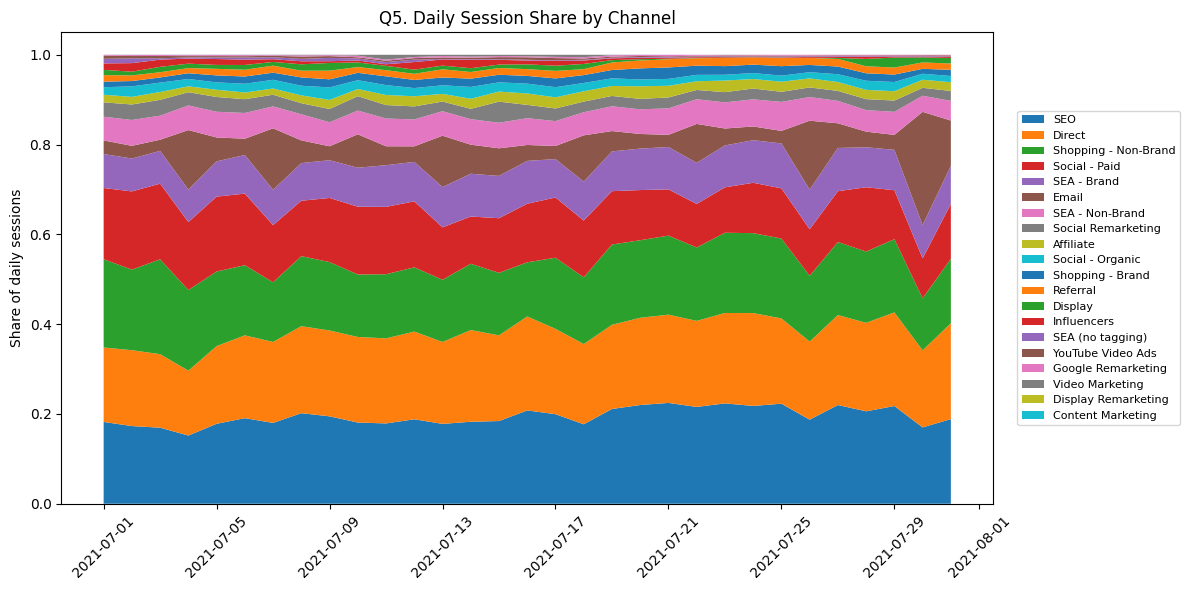

In [63]:
pivot_share = pivot_counts.div(pivot_counts.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 6))
plt.stackplot(
    pivot_share.index,
    pivot_share.T.values,
    labels=pivot_share.columns
)
plt.title("Q5. Daily Session Share by Channel")
plt.ylabel("Share of daily sessions")
plt.xticks(rotation=45)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

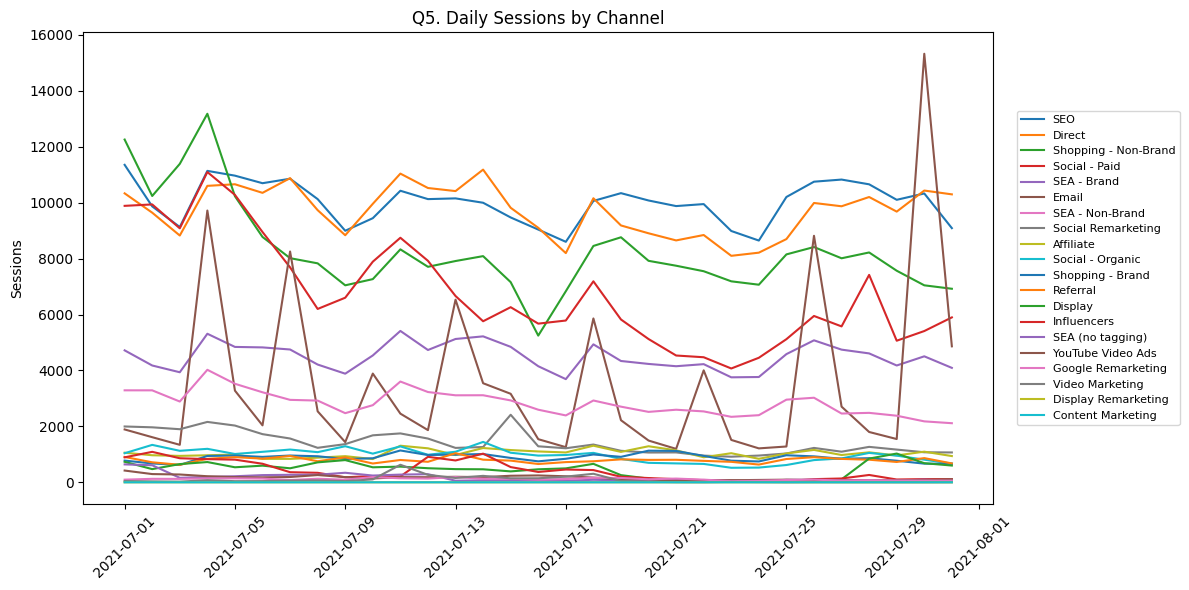

In [64]:
plt.figure(figsize=(12, 6))
for col in pivot_counts.columns:
    plt.plot(pivot_counts.index, pivot_counts[col], linewidth=1.5, label=col)
    
plt.title("Q5. Daily Sessions by Channel")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

After label harmonization, many channels look reasonably stable, but not all.  
In particular, **`Email`, `Display`, `Influencers`, `SEA (no tagging)`, and `Video Marketing`** appear unstable under the share-based stability check.

Q5 share-based stability summary:


,channel_name,mean_sessions,std_sessions,min_sessions,max_sessions,mean_share,std_share,min_share,max_share,share_cv,share_range_pp,segment,stability_class
18,Video Marketing,88.322581,130.474362,3.0,627.0,1.645362e-03,0.002329,0.000049,0.010757,1.415508,1.070775,regular,unstable
9,SEA (no tagging),165.129032,151.803545,42.0,640.0,3.042763e-03,0.002576,0.000981,0.010693,0.846704,0.971232,regular,unstable
5,Email,3554.225806,3212.517182,1195.0,15325.0,6.454647e-02,0.050534,0.024863,0.252180,0.782909,22.731719,regular,unstable
7,Influencers,402.870968,335.939354,33.0,1089.0,7.346105e-03,0.005740,0.000831,0.019090,0.781300,1.825881,regular,unstable
3,Display,454.290323,282.012316,16.0,1028.0,8.532307e-03,0.005461,0.000296,0.022148,0.640049,2.185149,regular,unstable
19,YouTube Video Ads,162.193548,84.864763,58.0,420.0,3.072589e-03,0.001477,0.001256,0.006739,0.480844,0.548327,regular,almost unstable
6,Google Remarketing,109.903226,38.366092,42.0,188.0,2.105652e-03,0.000686,0.000987,0.003580,0.325877,0.259258,regular,almost unstable
17,Social Remarketing,1409.677419,403.458250,915.0,2415.0,2.686068e-02,0.005825,0.017673,0.046957,0.216854,2.928383,regular,almost unstable
15,Social - Organic,963.451613,238.856001,519.0,1444.0,1.844293e-02,0.003895,0.012905,0.027914,0.211188,1.500831,regular,almost unstable
13,Shopping - Brand,882.064516,135.663784,619.0,1138.0,1.720012e-02,0.003349,0.010976,0.025479,0.194734,1.450320,regular,stable


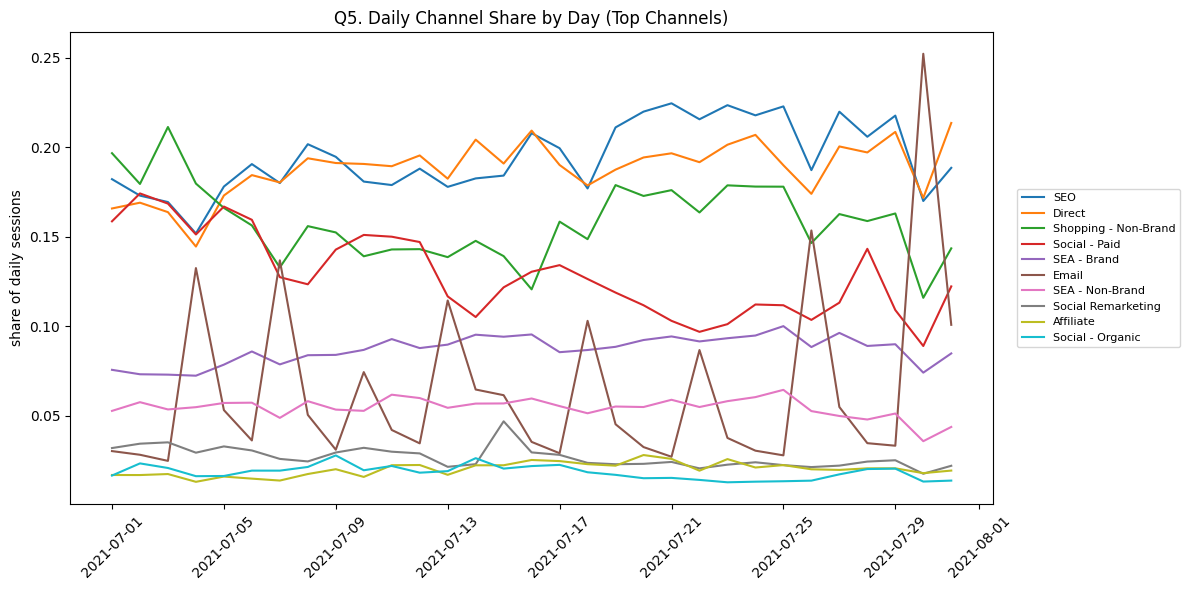

In [105]:
all_dates = pd.DataFrame({
    "event_date": pd.date_range(
        channel_daily_raw["event_date"].min(),
        channel_daily_raw["event_date"].max(),
        freq="D"
    )
})

all_channels = pd.DataFrame({
    "channel_name": sorted(channel_daily_raw["channel_name"].unique())
})

all_dates["key"] = 1
all_channels["key"] = 1

channel_grid = (
    all_dates
    .merge(all_channels, on="key")
    .drop(columns="key")
)

channel_daily_full = channel_grid.merge(
    channel_daily_raw,
    on=["event_date", "channel_name"],
    how="left"
)

channel_daily_full["sessions"] = channel_daily_full["sessions"].fillna(0)

daily_totals = (
    channel_daily_full
    .groupby("event_date", as_index=False)["sessions"]
    .sum()
    .rename(columns={"sessions": "total_sessions"})
)

channel_daily_full = channel_daily_full.merge(
    daily_totals,
    on="event_date",
    how="left"
)

channel_daily_full["session_share"] = np.where(
    channel_daily_full["total_sessions"] > 0,
    channel_daily_full["sessions"] / channel_daily_full["total_sessions"],
    0.0
)

share_stability_summary = (
    channel_daily_full
    .groupby("channel_name")
    .agg(
        mean_sessions=("sessions", "mean"),
        std_sessions=("sessions", "std"),
        min_sessions=("sessions", "min"),
        max_sessions=("sessions", "max"),
        mean_share=("session_share", "mean"),
        std_share=("session_share", "std"),
        min_share=("session_share", "min"),
        max_share=("session_share", "max"),
    )
    .reset_index()
)

share_stability_summary["std_sessions"] = share_stability_summary["std_sessions"].fillna(0)
share_stability_summary["std_share"] = share_stability_summary["std_share"].fillna(0)

# coefficient of variation.
share_stability_summary["share_cv"] = np.where(
    share_stability_summary["mean_share"] > 0,
    share_stability_summary["std_share"] / share_stability_summary["mean_share"],
    np.nan
)

share_stability_summary["share_range_pp"] = (
    (share_stability_summary["max_share"] - share_stability_summary["min_share"]) * 100
)


share_stability_eval = share_stability_summary.copy()
share_stability_eval["segment"] = "regular"
share_stability_eval.loc[share_stability_eval["mean_sessions"] < 50, "segment"] = "sparse"


share_stability_eval["stability_class"] = np.where(
    share_stability_eval["segment"] == "sparse",
    "sparse / too small",
    np.where(
        share_stability_eval["share_cv"] < 0.20,
        "stable",
        np.where(
            share_stability_eval["share_cv"] < 0.50,
            "almost unstable",
            "unstable"
        )
    )
)

share_stability_eval = share_stability_eval.sort_values(
    ["segment", "share_cv"],
    ascending=[True, False]
)

print("Q5 share-based stability summary:")
display(share_stability_eval)

# Optional visual: top channels by volume, but plotted as share through time
top_share_channels = channel_profile["channel_name"].head(10).tolist()

pivot_share_full = channel_daily_full.pivot(
    index="event_date",
    columns="channel_name",
    values="session_share"
).fillna(0)

plt.figure(figsize=(12, 6))
for col in top_share_channels:
    if col in pivot_share_full.columns:
        plt.plot(pivot_share_full.index, pivot_share_full[col], linewidth=1.5, label=col)

plt.title("Q5. Daily Channel Share by Day (Top Channels)")
plt.ylabel("share of daily sessions")
plt.xticks(rotation=45)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [106]:
regular_channels = share_stability_eval[share_stability_eval["segment"] == "regular"].copy()

q5_class_counts = (
    regular_channels["stability_class"]
    .value_counts()
    .rename_axis("stability_class")
    .reset_index(name="n_channels")
)

print("Q5 regular-channel class counts:")
display(q5_class_counts)

def format_channel_list(series):
    vals = series.tolist()
    return ", ".join(vals) if len(vals) > 0 else "none"

stable_channels = regular_channels.loc[
    regular_channels["stability_class"] == "stable", "channel_name"
]

almost_unstable_channels = regular_channels.loc[
    regular_channels["stability_class"] == "almost unstable", "channel_name"
]

unstable_channels = regular_channels.loc[
    regular_channels["stability_class"] == "unstable", "channel_name"
]

sparse_channels = share_stability_eval.loc[
    share_stability_eval["segment"] == "sparse", "channel_name"
]

print(
    f"""
Q5 takeaway:
- After harmonizing inconsistent channel names, most channels look reasonably stable, but not all.
- Using share of daily sessions (more appropriate than raw counts), stable regular channels are: {format_channel_list(stable_channels)}.
- Almost unstable regular channels are: {format_channel_list(almost_unstable_channels)}.
- Unstable regular channels are: {format_channel_list(unstable_channels)}.
- Sparse channels are kept separate because their volume is too small for a strong stability judgment: {format_channel_list(sparse_channels)}.
""".strip()
)

Q5 regular-channel class counts:


,stability_class,n_channels
0,stable,9
1,unstable,5
2,almost unstable,4


Q5 takeaway:
- After harmonizing inconsistent channel names, most channels look reasonably stable, but not all.
- Using share of daily sessions (more appropriate than raw counts), stable regular channels are: Shopping - Brand, Affiliate, Social - Paid, Shopping - Non-Brand, Referral, SEA - Non-Brand, SEO, SEA - Brand, Direct.
- Almost unstable regular channels are: YouTube Video Ads, Google Remarketing, Social Remarketing, Social - Organic.
- Unstable regular channels are: Video Marketing, SEA (no tagging), Email, Influencers, Display.
- Sparse channels are kept separate because their volume is too small for a strong stability judgment: Content Marketing, Display Remarketing.


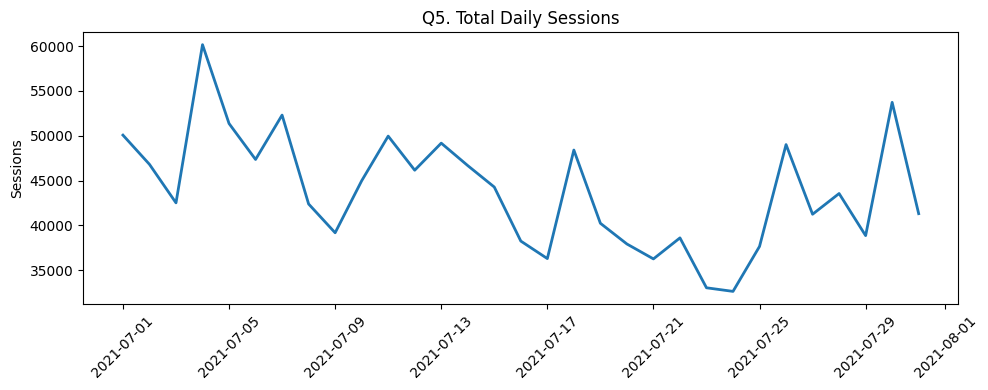

In [58]:
daily_total_sessions = pivot_counts.sum(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(daily_total_sessions.index, daily_total_sessions.values, linewidth=2)
plt.title("Q5. Total Daily Sessions")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Simple conclusion for Q5**

- There is a real **channel labeling issue**, because some channels appear under multiple names such as `Direct` / `Direct Traffic`, `SEA - Brand` / `SEA - Branded`, and `Social - Paid` / `Social Paid`.
- After harmonizing labels and evaluating **daily share of sessions** rather than raw counts, most regular channels look reasonably stable.
- However, a few regular channels still look unstable, especially **`Email`, `Display`, `Influencers`, `SEA (no tagging)`, and `Video Marketing`**.
- Therefore, the channeling issue is **not only naming inconsistency**; some channels also show meaningful instability over time.

# Q6) Bonus — Any other issues?

Below are a few small but useful extra checks.


In [74]:
api_zero_click_cost = pd.read_sql_query(
    """
    SELECT *
    FROM api_adwords_costs
    WHERE clicks = 0 AND cost > 0
    ORDER BY cost DESC
    """
, conn)

api_zero_click_cost.head(10)

,event_date,campaign_id,cost,clicks
0,2021-07-02,campaign_id_156,7.031,0
1,2021-07-17,campaign_id_94,6.975,0
2,2021-07-11,campaign_id_94,5.976,0
3,2021-07-04,campaign_id_94,3.908,0
4,2021-07-05,campaign_id_156,3.816,0
5,2021-07-10,campaign_id_94,3.458,0
6,2021-07-01,campaign_id_7,1.844,0
7,2021-07-20,campaign_id_94,1.368,0
8,2021-07-09,campaign_id_7,1.108,0
9,2021-07-20,campaign_id_7,1.067,0


There are a few campaigns with zero click-rate and non-zero cost. This is weird.

In [75]:
conv_zero = pd.read_sql_query("SELECT COUNT(*) AS n FROM conversions WHERE revenue = 0", conn)["n"].iloc[0]
backend_zero = pd.read_sql_query("SELECT COUNT(*) AS n FROM conversions_backend WHERE revenue = 0", conn)["n"].iloc[0]

print(f"conversions: {conv_zero} zero-revenue rows")
print(f"conversions_backend: {backend_zero} zero-revenue rows")


conversions: 197 zero-revenue rows
conversions_backend: 27 zero-revenue rows


In [91]:
other_issues = pd.DataFrame({
    "worth review": [
        "API rows with cost > 0 but clicks = 0",
        "Zero-revenue rows in conversions",
        "Zero-revenue rows in conversions_backend",
    ],
    "Count": [
        len(api_zero_click_cost),
        int(conv_zero),
        int(backend_zero),
    ]
})

other_issues


,worth review,Count
0,API rows with cost > 0 but clicks = 0,10
1,Zero-revenue rows in conversions,197
2,Zero-revenue rows in conversions_backend,27


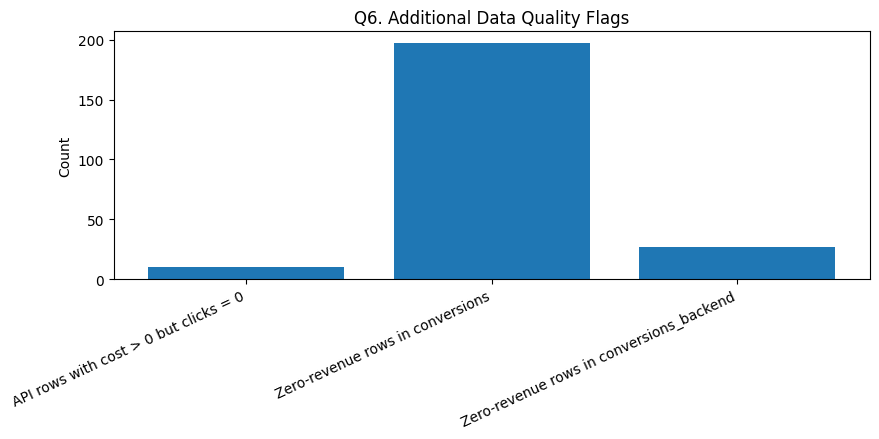

In [77]:
plt.figure(figsize=(9, 4.5))
plt.bar(other_issues["Issue"], other_issues["Count"])
plt.title("Q6. Additional Data Quality Flags")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Final summary

### Main findings
1. **Adwords cost coverage is high but incomplete.** The main problem campaign is `campaign_id_79`, and two campaigns are missing from session data.
2. **Conversions are fairly stable over the available period**, but the frontend table is below the backend table every day, suggesting systematic under-recording.
3. **Frontend conversions do not fully reconcile to backend truth.** The main defects are missing rows, zero-revenue frontend rows, and a small number of `user_id` mismatches.
4. **Attribution contains real integrity issues**, especially cross-user journeys and non-unit `ihc` sums. Row-level `ihc` errors also exist, although they are much rarer.
5. **Channel-level reporting has two issues:** inconsistent channel naming and instability in some channels even after names are standardized.

### Most important practical takeaway
If this were a real production system, the first fixes to prioritize would be:
- frontend conversion reconciliation against backend
- attribution logic and customer-journey linkage
- campaign and channel labeling standardization